# **Bag of Words (BOW) Text Classification**

This notebook demonstrates how to use TFIDF Vectorizer from scikit-learn

_______________

### **Set-Up**

This section focuses on loading the data, python libraries (which will be used throughout this notebook)

In [278]:
# Loading Libraries
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

print("--"*50)
print("Libraries loaded successfully.")
print("--"*50)

----------------------------------------------------------------------------------------------------
Libraries loaded successfully.
----------------------------------------------------------------------------------------------------


In [279]:
# Loading the dataset
data = pd.read_csv("data/english_pages_metadata_clean_with_labels.csv")
data_og = pd.read_csv("data/dataset_with_assignments.csv")

print("--"*50)
print("First few Rows of the Dataset:")
print("--"*50)
data

----------------------------------------------------------------------------------------------------
First few Rows of the Dataset:
----------------------------------------------------------------------------------------------------


,page_id,assigned_to,manual_label,manual_label_clean,manual_label_final,full_text,_merge
0,655.0,Vinay Varshigan Sivakumar Jayalakshmi,ecommerce,ECOMMERCE,ECOMMERCE,Fall arrest and work positioning harness – All...,both
1,656.0,Vinay Varshigan Sivakumar Jayalakshmi,blog,BLOG,BLOG,Vermont Mountain Eats: Jay Peak - All Mountain...,both
2,657.0,Vinay Varshigan Sivakumar Jayalakshmi,news,NEWS,NEWS,05/18/2020 Booking Report for Bulloch County -...,both
3,658.0,Vinay Varshigan Sivakumar Jayalakshmi,blog,BLOG,BLOG,Is Pickleball Easier than Tennis? | AllRacket\...,both
4,661.0,Vinay Varshigan Sivakumar Jayalakshmi,other,OTHER,OTHER,"Account Executive, Auto Finance - Greater Seat...",both
...,...,...,...,...,...,...,...
591,489.0,Jaee Oh,blog,BLOG,BLOG,Blog post Archives - 38th VoyageMystic Seaport...,both
592,490.0,Jaee Oh,ecommerce,ECOMMERCE,ECOMMERCE,Kids bike pedals collection 3D Model in Bicycl...,both
593,491.0,Jaee Oh,blog,BLOG,BLOG,3patchcrafts: February 2013\n3patchcrafts\nThe...,both
594,493.0,Jaee Oh,other,OTHER,OTHER,Fatal error: Uncaught mysqli_sql_exception: Ta...,both


In [280]:
data.drop(columns=["_merge"], inplace=True)

In [281]:
# Dataset Shape:
print("--"*50)
print("Dataset Shape (Rows, Columns)")
print("--"*50)
data.shape

----------------------------------------------------------------------------------------------------
Dataset Shape (Rows, Columns)
----------------------------------------------------------------------------------------------------


(596, 6)

In [282]:
# Dataset Information
print("--"*50)
print("Dataset Information")
print("--"*50)
data.info()

----------------------------------------------------------------------------------------------------
Dataset Information
----------------------------------------------------------------------------------------------------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 596 entries, 0 to 595
Data columns (total 6 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   page_id             596 non-null    float64
 1   assigned_to         596 non-null    object 
 2   manual_label        596 non-null    object 
 3   manual_label_clean  596 non-null    object 
 4   manual_label_final  596 non-null    object 
 5   full_text           596 non-null    object 
dtypes: float64(1), object(5)
memory usage: 28.1+ KB


In [283]:
# Identifying NULLs and NaNs in the data set
print("--"*50)
print("Null Values in the dataset")
print("--"*50)
print(data.isnull().sum())

----------------------------------------------------------------------------------------------------
Null Values in the dataset
----------------------------------------------------------------------------------------------------
page_id               0
assigned_to           0
manual_label          0
manual_label_clean    0
manual_label_final    0
full_text             0
dtype: int64


Based on the above information, it is clear from a bird’s-eye view that there are no null or NaN (except for manual_label) values or even duplication of rows within the dataset.

____________

### **1. Text Preprocessing**

In this section, the primary focus is on cleaning the text data.Identifying and removing these characters early is important, as they can cause issues later in the pipeline and can negatively impact stability and compatibility. The primary goal here is to retain ASCII characters, such as English letters, numbers, and common punctuation (e.g., '(', ')', '[', ']', '+', '-', ' '), while ensuring that the existing structure of the text remains unchanged.

#### **1.1 Filtering out the English Words**

Here we will focusing on removing all the non-english character and preserve currance symbols.  `\x00-\x7f` - ASCII Range: It starts from ASCII 00 and ends at ASCII 127. Here the "\x" is an escape sequence telling the regex engine that the next two character are a hexadecimal, "00" means the start the first ASCII value and "7f" is the hexadecimal value for 127.

In [284]:
# list of currency symbols (few of them might not be present, but still we will keep it)
currency_symbols = [
    # Paired (Multi-character) symbols (Longest first)
    'USD','AU$', 'C$', 'NZ$', 'HK$', 'S$', 'US$', 'NT$', 'MX$', 'R$', 'zł', 'Kč','₨',
    'kr', 'Ft', 'ден', 'р.', 'лв', '₡', '₢', '₣', '₥', 

    # Single character symbols (Specific before generic)
    '€', '£', '¥', '元', '₹', '฿', '₩', '₽', '₪', '₺', '₦', '₵', '₫', 
    '₱', '₭', '₮', '₼', '₸', '₴', '៛', '₲', '₡', '₾', '֏', '﷼', 'Ξ', 'Ł', '$'
]

curr_symbols = ''.join(re.escape(s) for s in currency_symbols)
# function to clean the full text column
def full_text_clean (text):
    #Regex Pattern to indentify all the ASCII characters while retaining currency symbols
    re_pattern = rf"[\x00-\x7F{curr_symbols}]+"

    clean = re.findall(re_pattern, text)

    return clean

In [285]:
data['full_text_clean'] = data['full_text'].apply(full_text_clean)
data_og['full_text_clean'] = data_og['full_text'].apply(full_text_clean)

print("--"*50)
print("New datastructure after cleaning the full_text columns:")
print("--"*50)
data

----------------------------------------------------------------------------------------------------
New datastructure after cleaning the full_text columns:
----------------------------------------------------------------------------------------------------


,page_id,assigned_to,manual_label,manual_label_clean,manual_label_final,full_text,full_text_clean
0,655.0,Vinay Varshigan Sivakumar Jayalakshmi,ecommerce,ECOMMERCE,ECOMMERCE,Fall arrest and work positioning harness – All...,"[Fall arrest and work positioning harness , A..."
1,656.0,Vinay Varshigan Sivakumar Jayalakshmi,blog,BLOG,BLOG,Vermont Mountain Eats: Jay Peak - All Mountain...,[Vermont Mountain Eats: Jay Peak - All Mountai...
2,657.0,Vinay Varshigan Sivakumar Jayalakshmi,news,NEWS,NEWS,05/18/2020 Booking Report for Bulloch County -...,[05/18/2020 Booking Report for Bulloch County ...
3,658.0,Vinay Varshigan Sivakumar Jayalakshmi,blog,BLOG,BLOG,Is Pickleball Easier than Tennis? | AllRacket\...,[Is Pickleball Easier than Tennis? | AllRacket...
4,661.0,Vinay Varshigan Sivakumar Jayalakshmi,other,OTHER,OTHER,"Account Executive, Auto Finance - Greater Seat...","[Account Executive, Auto Finance - Greater Sea..."
...,...,...,...,...,...,...,...
591,489.0,Jaee Oh,blog,BLOG,BLOG,Blog post Archives - 38th VoyageMystic Seaport...,[Blog post Archives - 38th VoyageMystic Seapor...
592,490.0,Jaee Oh,ecommerce,ECOMMERCE,ECOMMERCE,Kids bike pedals collection 3D Model in Bicycl...,[Kids bike pedals collection 3D Model in Bicyc...
593,491.0,Jaee Oh,blog,BLOG,BLOG,3patchcrafts: February 2013\n3patchcrafts\nThe...,[3patchcrafts: February 2013\n3patchcrafts\nTh...
594,493.0,Jaee Oh,other,OTHER,OTHER,Fatal error: Uncaught mysqli_sql_exception: Ta...,[Fatal error: Uncaught mysqli_sql_exception: T...


#### **1.2 Removal of Emails**

Removing email addresses because they are primarily alphanumeric in nature and do not carry meaningful semantic information. They also do not contribute as reliable features for text classification and may instead introduce noise into the model

In [286]:
def extract_emails(text):
    """
    Removing all email addresses from text
    """
    # Regex pattern for emails
    email_pattern = r'\b[A-Za-z0-9._%+-]+@[A-Za-z0-9.-]+\.[A-Z|a-z]{2,}\b'
    clean_text = []
    
    # Find all matches
    for i in range (len(text)):
        clean_text.append(re.sub(email_pattern, '', text[i]))
    
    return clean_text

In [287]:
data['full_text_clean'] = data['full_text_clean'].apply(extract_emails)
data_og['full_text_clean'] = data_og['full_text_clean'].apply(extract_emails)

print("--"*50)
print("Email Removal:")
print("--"*50)
data

----------------------------------------------------------------------------------------------------
Email Removal:
----------------------------------------------------------------------------------------------------


,page_id,assigned_to,manual_label,manual_label_clean,manual_label_final,full_text,full_text_clean
0,655.0,Vinay Varshigan Sivakumar Jayalakshmi,ecommerce,ECOMMERCE,ECOMMERCE,Fall arrest and work positioning harness – All...,"[Fall arrest and work positioning harness , A..."
1,656.0,Vinay Varshigan Sivakumar Jayalakshmi,blog,BLOG,BLOG,Vermont Mountain Eats: Jay Peak - All Mountain...,[Vermont Mountain Eats: Jay Peak - All Mountai...
2,657.0,Vinay Varshigan Sivakumar Jayalakshmi,news,NEWS,NEWS,05/18/2020 Booking Report for Bulloch County -...,[05/18/2020 Booking Report for Bulloch County ...
3,658.0,Vinay Varshigan Sivakumar Jayalakshmi,blog,BLOG,BLOG,Is Pickleball Easier than Tennis? | AllRacket\...,[Is Pickleball Easier than Tennis? | AllRacket...
4,661.0,Vinay Varshigan Sivakumar Jayalakshmi,other,OTHER,OTHER,"Account Executive, Auto Finance - Greater Seat...","[Account Executive, Auto Finance - Greater Sea..."
...,...,...,...,...,...,...,...
591,489.0,Jaee Oh,blog,BLOG,BLOG,Blog post Archives - 38th VoyageMystic Seaport...,[Blog post Archives - 38th VoyageMystic Seapor...
592,490.0,Jaee Oh,ecommerce,ECOMMERCE,ECOMMERCE,Kids bike pedals collection 3D Model in Bicycl...,[Kids bike pedals collection 3D Model in Bicyc...
593,491.0,Jaee Oh,blog,BLOG,BLOG,3patchcrafts: February 2013\n3patchcrafts\nThe...,[3patchcrafts: February 2013\n3patchcrafts\nTh...
594,493.0,Jaee Oh,other,OTHER,OTHER,Fatal error: Uncaught mysqli_sql_exception: Ta...,[Fatal error: Uncaught mysqli_sql_exception: T...


#### **1.3 Removel of Phone Numbers**

Phone numbers do not carry meaningful semantic information for text classification, so it is better to remove them rather than retain them.

In [288]:
def extract_phones(text):
    """
    Extract phone numbers in various formats
    Returns: list of phone numbers
    """
    clean_text = []
    
    # Pattern 1: 555-123-4567
    pattern1 = r'\b\d{3}-\d{3}-\d{4}\b'
    # Pattern 2: (555) 123-4567
    pattern2 = r'\(\d{3}\)\s*\d{3}-\d{4}'
    # Pattern 3: 800-555-0123 (toll-free)
    pattern3 = r'\b[8-9]00-\d{3}-\d{4}\b'
    # Pattern 4: +1-555-123-4567
    pattern4 = r'\+{1,3}-\d{3}-\d{3}-\d{4}'
    # Pattern 5 : +267 7610 0890
    pattern5 = r'\+\d{3}\s*\d{4}\s*\d{4}'

    for i in range (len(text)):
        clean_text.append(re.sub(pattern1, '', text[i]))
        clean_text.append(re.sub(pattern2, '', text[i]))
        clean_text.append(re.sub(pattern3, '', text[i]))
        clean_text.append(re.sub(pattern4, '', text[i]))
        clean_text.append(re.sub(pattern5, '', text[i]))
           
    return clean_text

In [289]:
data['full_text_clean'] = data['full_text_clean'].apply(extract_phones)
data_og['full_text_clean'] = data_og['full_text_clean'].apply(extract_phones)

print("--"*50)
print("Phone Number Removal:")
print("--"*50)
data

----------------------------------------------------------------------------------------------------
Phone Number Removal:
----------------------------------------------------------------------------------------------------


,page_id,assigned_to,manual_label,manual_label_clean,manual_label_final,full_text,full_text_clean
0,655.0,Vinay Varshigan Sivakumar Jayalakshmi,ecommerce,ECOMMERCE,ECOMMERCE,Fall arrest and work positioning harness – All...,"[Fall arrest and work positioning harness , Fa..."
1,656.0,Vinay Varshigan Sivakumar Jayalakshmi,blog,BLOG,BLOG,Vermont Mountain Eats: Jay Peak - All Mountain...,[Vermont Mountain Eats: Jay Peak - All Mountai...
2,657.0,Vinay Varshigan Sivakumar Jayalakshmi,news,NEWS,NEWS,05/18/2020 Booking Report for Bulloch County -...,[05/18/2020 Booking Report for Bulloch County ...
3,658.0,Vinay Varshigan Sivakumar Jayalakshmi,blog,BLOG,BLOG,Is Pickleball Easier than Tennis? | AllRacket\...,[Is Pickleball Easier than Tennis? | AllRacket...
4,661.0,Vinay Varshigan Sivakumar Jayalakshmi,other,OTHER,OTHER,"Account Executive, Auto Finance - Greater Seat...","[Account Executive, Auto Finance - Greater Sea..."
...,...,...,...,...,...,...,...
591,489.0,Jaee Oh,blog,BLOG,BLOG,Blog post Archives - 38th VoyageMystic Seaport...,[Blog post Archives - 38th VoyageMystic Seapor...
592,490.0,Jaee Oh,ecommerce,ECOMMERCE,ECOMMERCE,Kids bike pedals collection 3D Model in Bicycl...,[Kids bike pedals collection 3D Model in Bicyc...
593,491.0,Jaee Oh,blog,BLOG,BLOG,3patchcrafts: February 2013\n3patchcrafts\nThe...,[3patchcrafts: February 2013\n3patchcrafts\nTh...
594,493.0,Jaee Oh,other,OTHER,OTHER,Fatal error: Uncaught mysqli_sql_exception: Ta...,[Fatal error: Uncaught mysqli_sql_exception: T...


#### **1.4 Removing Dates**

Dates may add some contextual information, they do not carry meaningful semantic value for text classification and therefore do not meaningfully contribute to the model.

In [290]:
def extract_dates(text):
    """
    Extract phone numbers in various formats
    Returns: list of phone numbers
    """
    clean_text = []
    
    # Pattern 1: YYYY-MM-DD
    pattern1 = r'\d{4}-\d{2}-\d{2}'
    # Pattern 2: DD-MM-YYYY or MM-DD-YYYY
    pattern2 = r'\d{2}-\d{2}-\d{4}'
    # Pattern 3: MM/DD/YYYY or DD/MM/YYYY
    pattern3 = r'\d{2}/\d{2}/\d{4}'
    # Pattern 4: January 15, 2024 or Jan 15, 2024
    pattern4 = r'(?:Jan|Feb|Mar|Apr|May|Jun|Jul|Aug|Sep|Sept|Oct|Nov|Dec)[a-z]*\s\d{1,2},\s\d{4}'
    # Pattern 5: 18 May. 2025 | 17 May 2025
    pattern5 = r'\d{1,2}\s(?:Jan|Feb|Mar|Apr|May|Jun|Jul|Aug|Sep|Sept|Oct|Nov|Dec)[a-z]*\.?\s\d{4}'
    # pattern 6: 2024.01.15
    pattern6 = r'\d{4}\.\d{2}\.\d{2}'

    for i in range (len(text)):
        clean_text.append(re.sub(pattern1, '', text[i]))
        clean_text.append(re.sub(pattern2, '', text[i]))
        clean_text.append(re.sub(pattern3, '', text[i]))
        clean_text.append(re.sub(pattern4, '', text[i]))
        clean_text.append(re.sub(pattern5, '', text[i]))
        clean_text.append(re.sub(pattern6, '', text[i]))
           
    return clean_text

In [291]:
data['full_text_clean'] = data['full_text_clean'].apply(extract_dates)
data_og['full_text_clean'] = data_og['full_text_clean'].apply(extract_dates)

print("--"*50)
print("Date Removal:")
print("--"*50)
data

----------------------------------------------------------------------------------------------------
Date Removal:
----------------------------------------------------------------------------------------------------


,page_id,assigned_to,manual_label,manual_label_clean,manual_label_final,full_text,full_text_clean
0,655.0,Vinay Varshigan Sivakumar Jayalakshmi,ecommerce,ECOMMERCE,ECOMMERCE,Fall arrest and work positioning harness – All...,"[Fall arrest and work positioning harness , Fa..."
1,656.0,Vinay Varshigan Sivakumar Jayalakshmi,blog,BLOG,BLOG,Vermont Mountain Eats: Jay Peak - All Mountain...,[Vermont Mountain Eats: Jay Peak - All Mountai...
2,657.0,Vinay Varshigan Sivakumar Jayalakshmi,news,NEWS,NEWS,05/18/2020 Booking Report for Bulloch County -...,[05/18/2020 Booking Report for Bulloch County ...
3,658.0,Vinay Varshigan Sivakumar Jayalakshmi,blog,BLOG,BLOG,Is Pickleball Easier than Tennis? | AllRacket\...,[Is Pickleball Easier than Tennis? | AllRacket...
4,661.0,Vinay Varshigan Sivakumar Jayalakshmi,other,OTHER,OTHER,"Account Executive, Auto Finance - Greater Seat...","[Account Executive, Auto Finance - Greater Sea..."
...,...,...,...,...,...,...,...
591,489.0,Jaee Oh,blog,BLOG,BLOG,Blog post Archives - 38th VoyageMystic Seaport...,[Blog post Archives - 38th VoyageMystic Seapor...
592,490.0,Jaee Oh,ecommerce,ECOMMERCE,ECOMMERCE,Kids bike pedals collection 3D Model in Bicycl...,[Kids bike pedals collection 3D Model in Bicyc...
593,491.0,Jaee Oh,blog,BLOG,BLOG,3patchcrafts: February 2013\n3patchcrafts\nThe...,[3patchcrafts: February 2013\n3patchcrafts\nTh...
594,493.0,Jaee Oh,other,OTHER,OTHER,Fatal error: Uncaught mysqli_sql_exception: Ta...,[Fatal error: Uncaught mysqli_sql_exception: T...


#### **1.5 Removing all the URLs**

Removing URLs from the text will reduce its overall length. In turn, this helps us retain only the most relevant content for text classification.

In [292]:
def extract_urls(text):
    """
    Remove URLs from text while preserving everything else
    """
    url_pattern = r'https?://\S+|www\.\S+'

    clean_text = []
    # Find all matches
    for i in range (len(text)):
        clean_text.append(re.sub(url_pattern, '', text[i]))
    
    return clean_text

In [293]:
data['full_text_clean'] = data['full_text_clean'].apply(extract_urls)
data_og['full_text_clean'] = data_og['full_text_clean'].apply(extract_urls)

print("--"*50)
print("URL Removal:")
print("--"*50)
data 

----------------------------------------------------------------------------------------------------
URL Removal:
----------------------------------------------------------------------------------------------------


,page_id,assigned_to,manual_label,manual_label_clean,manual_label_final,full_text,full_text_clean
0,655.0,Vinay Varshigan Sivakumar Jayalakshmi,ecommerce,ECOMMERCE,ECOMMERCE,Fall arrest and work positioning harness – All...,"[Fall arrest and work positioning harness , Fa..."
1,656.0,Vinay Varshigan Sivakumar Jayalakshmi,blog,BLOG,BLOG,Vermont Mountain Eats: Jay Peak - All Mountain...,[Vermont Mountain Eats: Jay Peak - All Mountai...
2,657.0,Vinay Varshigan Sivakumar Jayalakshmi,news,NEWS,NEWS,05/18/2020 Booking Report for Bulloch County -...,[05/18/2020 Booking Report for Bulloch County ...
3,658.0,Vinay Varshigan Sivakumar Jayalakshmi,blog,BLOG,BLOG,Is Pickleball Easier than Tennis? | AllRacket\...,[Is Pickleball Easier than Tennis? | AllRacket...
4,661.0,Vinay Varshigan Sivakumar Jayalakshmi,other,OTHER,OTHER,"Account Executive, Auto Finance - Greater Seat...","[Account Executive, Auto Finance - Greater Sea..."
...,...,...,...,...,...,...,...
591,489.0,Jaee Oh,blog,BLOG,BLOG,Blog post Archives - 38th VoyageMystic Seaport...,[Blog post Archives - 38th VoyageMystic Seapor...
592,490.0,Jaee Oh,ecommerce,ECOMMERCE,ECOMMERCE,Kids bike pedals collection 3D Model in Bicycl...,[Kids bike pedals collection 3D Model in Bicyc...
593,491.0,Jaee Oh,blog,BLOG,BLOG,3patchcrafts: February 2013\n3patchcrafts\nThe...,[3patchcrafts: February 2013\n3patchcrafts\nTh...
594,493.0,Jaee Oh,other,OTHER,OTHER,Fatal error: Uncaught mysqli_sql_exception: Ta...,[Fatal error: Uncaught mysqli_sql_exception: T...


#### **1.6 Replacing `\r`,  `\n`, and tabs `\t` with Space**

Replacing `\r`, `\n` and `\t` with a space removes the ambiguity caused when text appears on a new line but is recorded as `\n` or has extra spaces and recorded as `\t`, resulting in a single continuous text line.

In [294]:
# Cleaning "\n" from the cleaned full_text column
def clean_text(text):
    clean = r"[\r\n\t]+"

    sentence = []

    # Find all matches
    for i in range (len(text)):
        sentence.append(re.sub(clean, " ", text[i]))

    sentence = [stn for stn in sentence if stn]

    return sentence

data['full_text_clean'] = data['full_text_clean'].apply(clean_text)
data_og['full_text_clean'] = data_og['full_text_clean'].apply(clean_text)

print("--"*50)
print("New datastructure after cleaning the full_text columns:")
print("--"*50)
data

----------------------------------------------------------------------------------------------------
New datastructure after cleaning the full_text columns:
----------------------------------------------------------------------------------------------------


,page_id,assigned_to,manual_label,manual_label_clean,manual_label_final,full_text,full_text_clean
0,655.0,Vinay Varshigan Sivakumar Jayalakshmi,ecommerce,ECOMMERCE,ECOMMERCE,Fall arrest and work positioning harness – All...,"[Fall arrest and work positioning harness , Fa..."
1,656.0,Vinay Varshigan Sivakumar Jayalakshmi,blog,BLOG,BLOG,Vermont Mountain Eats: Jay Peak - All Mountain...,[Vermont Mountain Eats: Jay Peak - All Mountai...
2,657.0,Vinay Varshigan Sivakumar Jayalakshmi,news,NEWS,NEWS,05/18/2020 Booking Report for Bulloch County -...,[05/18/2020 Booking Report for Bulloch County ...
3,658.0,Vinay Varshigan Sivakumar Jayalakshmi,blog,BLOG,BLOG,Is Pickleball Easier than Tennis? | AllRacket\...,[Is Pickleball Easier than Tennis? | AllRacket...
4,661.0,Vinay Varshigan Sivakumar Jayalakshmi,other,OTHER,OTHER,"Account Executive, Auto Finance - Greater Seat...","[Account Executive, Auto Finance - Greater Sea..."
...,...,...,...,...,...,...,...
591,489.0,Jaee Oh,blog,BLOG,BLOG,Blog post Archives - 38th VoyageMystic Seaport...,[Blog post Archives - 38th VoyageMystic Seapor...
592,490.0,Jaee Oh,ecommerce,ECOMMERCE,ECOMMERCE,Kids bike pedals collection 3D Model in Bicycl...,[Kids bike pedals collection 3D Model in Bicyc...
593,491.0,Jaee Oh,blog,BLOG,BLOG,3patchcrafts: February 2013\n3patchcrafts\nThe...,[3patchcrafts: February 2013 3patchcrafts The ...
594,493.0,Jaee Oh,other,OTHER,OTHER,Fatal error: Uncaught mysqli_sql_exception: Ta...,[Fatal error: Uncaught mysqli_sql_exception: T...


In [295]:
# Random index number to check how a full_text field and full_text_clean field looks like
idx = np.random.randint(0, 596)
print("--"*50)
print(f"Text Field ({idx}) -- Total Character Length ({len(data.loc[idx, 'full_text_clean'])})")
print("--"*50)
print(data.loc[idx, 'full_text_clean'][:3])

----------------------------------------------------------------------------------------------------
Text Field (162) -- Total Character Length (1080)
----------------------------------------------------------------------------------------------------
['Get Ready for More Hype From Climate Fearmongers - Christianity House Christianity House Environment News Enterprise Gadgets Mobile Technology Privacy Policy Disclaimer Whitelist News Get Ready for More Hype From Climate Fearmongers admin November 26, 2022, 5:01 am November 26, 2022 Comments Off on Get Ready for More Hype From Climate Fearmongers 308 News Nicaea and the Nearby Disease Can We Trust Election Machines Designed in Venezuela by Marxists? Do We REALLY Have Free Will? Christian Filmmaker Banned From Filming at Historic Site Over His ', 'Get Ready for More Hype From Climate Fearmongers - Christianity House Christianity House Environment News Enterprise Gadgets Mobile Technology Privacy Policy Disclaimer Whitelist News Get Ready

As you can see, we currently have a list-of-lists structure, which can be difficult to manage in the subsequent steps of the execution. Therefore, we will combine it into a single list for simplicity and easier processing.

In [296]:
data['full_text_merge'] = data['full_text_clean'].apply(lambda x: ' '.join(x))
data_og['full_text_merge'] = data_og['full_text_clean'].apply(lambda x: ' '.join(x))

print("--"*50)
print("New datastructure after combining the list-of-list structure into one single list:")
print("--"*50)
data

----------------------------------------------------------------------------------------------------
New datastructure after combining the list-of-list structure into one single list:
----------------------------------------------------------------------------------------------------


,page_id,assigned_to,manual_label,manual_label_clean,manual_label_final,full_text,full_text_clean,full_text_merge
0,655.0,Vinay Varshigan Sivakumar Jayalakshmi,ecommerce,ECOMMERCE,ECOMMERCE,Fall arrest and work positioning harness – All...,"[Fall arrest and work positioning harness , Fa...",Fall arrest and work positioning harness Fall...
1,656.0,Vinay Varshigan Sivakumar Jayalakshmi,blog,BLOG,BLOG,Vermont Mountain Eats: Jay Peak - All Mountain...,[Vermont Mountain Eats: Jay Peak - All Mountai...,Vermont Mountain Eats: Jay Peak - All Mountain...
2,657.0,Vinay Varshigan Sivakumar Jayalakshmi,news,NEWS,NEWS,05/18/2020 Booking Report for Bulloch County -...,[05/18/2020 Booking Report for Bulloch County ...,05/18/2020 Booking Report for Bulloch County -...
3,658.0,Vinay Varshigan Sivakumar Jayalakshmi,blog,BLOG,BLOG,Is Pickleball Easier than Tennis? | AllRacket\...,[Is Pickleball Easier than Tennis? | AllRacket...,Is Pickleball Easier than Tennis? | AllRacket ...
4,661.0,Vinay Varshigan Sivakumar Jayalakshmi,other,OTHER,OTHER,"Account Executive, Auto Finance - Greater Seat...","[Account Executive, Auto Finance - Greater Sea...","Account Executive, Auto Finance - Greater Seat..."
...,...,...,...,...,...,...,...,...
591,489.0,Jaee Oh,blog,BLOG,BLOG,Blog post Archives - 38th VoyageMystic Seaport...,[Blog post Archives - 38th VoyageMystic Seapor...,Blog post Archives - 38th VoyageMystic Seaport...
592,490.0,Jaee Oh,ecommerce,ECOMMERCE,ECOMMERCE,Kids bike pedals collection 3D Model in Bicycl...,[Kids bike pedals collection 3D Model in Bicyc...,Kids bike pedals collection 3D Model in Bicycl...
593,491.0,Jaee Oh,blog,BLOG,BLOG,3patchcrafts: February 2013\n3patchcrafts\nThe...,[3patchcrafts: February 2013 3patchcrafts The ...,3patchcrafts: February 2013 3patchcrafts The p...
594,493.0,Jaee Oh,other,OTHER,OTHER,Fatal error: Uncaught mysqli_sql_exception: Ta...,[Fatal error: Uncaught mysqli_sql_exception: T...,Fatal error: Uncaught mysqli_sql_exception: Ta...


In [297]:
idx = np.random.randint(0, 596)
print("--"*50)
print(f"Text Field ({idx}) -- Total Character Length ({len(data.loc[idx, 'full_text_merge'])})")
print("--"*50)
print(data.loc[idx, 'full_text_merge'][:1000])

----------------------------------------------------------------------------------------------------
Text Field (150) -- Total Character Length (247979)
----------------------------------------------------------------------------------------------------
BOFCA REVIEW ROUND-UP: 10/14/2016 | Boston Online Film Critics Association Skip to primary content Boston Online Film Critics Association The Boston Online Film Critics Association was established in May of 2012 to foster a community of web-based film critics. Search Main menu Home About Awards 2012 Awards Bob Chipman BOFCA REVIEW ROUND-UP: 10/14/2016 | Boston Online Film Critics Association Skip to primary content Boston Online Film Critics Association The Boston Online Film Critics Association was established in May of 2012 to foster a community of web-based film critics. Search Main menu Home About Awards 2012 Awards Bob Chipman BOFCA REVIEW ROUND-UP:  | Boston Online Film Critics Association Skip to primary content Boston Online Fil

In [298]:
print("--"*50)
print(f"Text Field ({idx}) -- Total Character Length ({len(data.loc[idx, 'full_text_clean'])})")
print("--"*50)
print(data.loc[idx, 'full_text_clean'][:3])

----------------------------------------------------------------------------------------------------
Text Field (150) -- Total Character Length (7380)
----------------------------------------------------------------------------------------------------
['BOFCA REVIEW ROUND-UP: 10/14/2016 | Boston Online Film Critics Association Skip to primary content Boston Online Film Critics Association The Boston Online Film Critics Association was established in May of 2012 to foster a community of web-based film critics. Search Main menu Home About Awards 2012 Awards Bob Chipman', 'BOFCA REVIEW ROUND-UP: 10/14/2016 | Boston Online Film Critics Association Skip to primary content Boston Online Film Critics Association The Boston Online Film Critics Association was established in May of 2012 to foster a community of web-based film critics. Search Main menu Home About Awards 2012 Awards Bob Chipman', 'BOFCA REVIEW ROUND-UP:  | Boston Online Film Critics Association Skip to primary content Boston Onli

#### **1.7 Normalizing Text**

Here we will convert all the sentences in the lower case, remove extra spaces, drop all the number, and punctuation using regex expression.

In [299]:
def normalize_text(text):
    
    pattern = rf'(?<!{curr_symbols})\b\d+(?:\.\d+)?\b(?!{curr_symbols})'
    text = re.sub(pattern, '', text)
    text = text.lower()
    text = re.sub(r"[^\w\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    
    return text.lower()

In [300]:
data['full_text_merge'] = data['full_text_merge'].apply(normalize_text)

print("--"*50)
print("New datastructure after converting the full_text_merge column to lowercase:")
print("--"*50)
data

----------------------------------------------------------------------------------------------------
New datastructure after converting the full_text_merge column to lowercase:
----------------------------------------------------------------------------------------------------


,page_id,assigned_to,manual_label,manual_label_clean,manual_label_final,full_text,full_text_clean,full_text_merge
0,655.0,Vinay Varshigan Sivakumar Jayalakshmi,ecommerce,ECOMMERCE,ECOMMERCE,Fall arrest and work positioning harness – All...,"[Fall arrest and work positioning harness , Fa...",fall arrest and work positioning harness fall ...
1,656.0,Vinay Varshigan Sivakumar Jayalakshmi,blog,BLOG,BLOG,Vermont Mountain Eats: Jay Peak - All Mountain...,[Vermont Mountain Eats: Jay Peak - All Mountai...,vermont mountain eats jay peak all mountain ma...
2,657.0,Vinay Varshigan Sivakumar Jayalakshmi,news,NEWS,NEWS,05/18/2020 Booking Report for Bulloch County -...,[05/18/2020 Booking Report for Bulloch County ...,booking report for bulloch county allongeorgia...
3,658.0,Vinay Varshigan Sivakumar Jayalakshmi,blog,BLOG,BLOG,Is Pickleball Easier than Tennis? | AllRacket\...,[Is Pickleball Easier than Tennis? | AllRacket...,is pickleball easier than tennis allracket ski...
4,661.0,Vinay Varshigan Sivakumar Jayalakshmi,other,OTHER,OTHER,"Account Executive, Auto Finance - Greater Seat...","[Account Executive, Auto Finance - Greater Sea...",account executive auto finance greater seattle...
...,...,...,...,...,...,...,...,...
591,489.0,Jaee Oh,blog,BLOG,BLOG,Blog post Archives - 38th VoyageMystic Seaport...,[Blog post Archives - 38th VoyageMystic Seapor...,blog post archives 38th voyagemystic seaport t...
592,490.0,Jaee Oh,ecommerce,ECOMMERCE,ECOMMERCE,Kids bike pedals collection 3D Model in Bicycl...,[Kids bike pedals collection 3D Model in Bicyc...,kids bike pedals collection 3d model in bicycl...
593,491.0,Jaee Oh,blog,BLOG,BLOG,3patchcrafts: February 2013\n3patchcrafts\nThe...,[3patchcrafts: February 2013 3patchcrafts The ...,3patchcrafts february 3patchcrafts the place t...
594,493.0,Jaee Oh,other,OTHER,OTHER,Fatal error: Uncaught mysqli_sql_exception: Ta...,[Fatal error: Uncaught mysqli_sql_exception: T...,fatal error uncaught mysqli_sql_exception tabl...


In [301]:
data_og['full_text_merge'] = data_og['full_text_merge'].apply(normalize_text)

In [302]:
# Sanity check for the full_text_merge column
idx = np.random.randint(0, 596)
print("--"*50)
print(f"Text Field ({idx}) -- Total Character Length ({len(data.loc[idx, 'full_text_merge'])})")
print("--"*50)
print(data.loc[idx, 'full_text_merge'][:1000])

----------------------------------------------------------------------------------------------------
Text Field (503) -- Total Character Length (1214459)
----------------------------------------------------------------------------------------------------
top cardio classes in dubai uae burn calories boost energy with orangetheory fitness blogosm blogosm write earn shop blogosm top cardio classes in dubai uae burn calories boost energy with orangetheory fitness blogosm blogosm write earn shop blogosm top cardio classes in dubai uae burn calories boost energy with orangetheory fitness blogosm blogosm write earn shop blogosm top cardio classes in dubai uae burn calories boost energy with orangetheory fitness blogosm blogosm write earn shop blogosm top cardio classes in dubai uae burn calories boost energy with orangetheory fitness blogosm blogosm write earn shop blogosm top cardio classes in dubai uae burn calories boost energy with orangetheory fitness blogosm blogosm write earn shop blo

In [303]:
print("--"*50)
print(f"Text Field ({idx}) -- Total Character Length ({len(data.loc[idx, 'full_text_clean'])})")
print("--"*50)
print(data.loc[idx, 'full_text_clean'][:3])

----------------------------------------------------------------------------------------------------
Text Field (503) -- Total Character Length (2160)
----------------------------------------------------------------------------------------------------
['Top Cardio Classes in Dubai, UAE: Burn Calories & Boost Energy with Orangetheory Fitness - Blogosm BlogOSM Write & Earn Shop.BlogOSM ', 'Top Cardio Classes in Dubai, UAE: Burn Calories & Boost Energy with Orangetheory Fitness - Blogosm BlogOSM Write & Earn Shop.BlogOSM ', 'Top Cardio Classes in Dubai, UAE: Burn Calories & Boost Energy with Orangetheory Fitness - Blogosm BlogOSM Write & Earn Shop.BlogOSM ']


#### **1.8 Removal of Stop Words**

These are common repeating words in a sentence, such as “a,” “the,” “he,” and “there.” These words typically carry little semantic meaning on their own, as they primarily serve grammatical functions. In this assignment, where our goal is to identify meaningful classification terms, such stopwords would dominate the corpus because they appear in nearly all sentences, thereby adding noise rather than useful information.

In [304]:
# loading stopwords from both sklearn and nltk
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS
from nltk.corpus import stopwords

nltk_stopwords = set(stopwords.words('english'))
sklearn_stopwords = set(ENGLISH_STOP_WORDS)

print("--"*50)
print("Number of NLTK stopwords:",len(nltk_stopwords), "\nStopwords from NLTK:", list(nltk_stopwords)[:10], "...")
print("--"*50)
print("Number of Sklearn stopwords:",len(sklearn_stopwords), "\nStopwords from Sklearn:", list(sklearn_stopwords)[:10], "...")
print("--"*50)

----------------------------------------------------------------------------------------------------
Number of NLTK stopwords: 198 
Stopwords from NLTK: ["mightn't", 'she', 'will', 'during', 'theirs', 'other', 'just', "don't", 'when', 'of'] ...
----------------------------------------------------------------------------------------------------
Number of Sklearn stopwords: 318 
Stopwords from Sklearn: ['she', 'nevertheless', 'five', 'others', 'meanwhile', 'than', 'side', 'therein', 'there', 'whether'] ...
----------------------------------------------------------------------------------------------------


In [305]:
# Chceking the common stopwords between both libraries
common_stopwords = nltk_stopwords.intersection(sklearn_stopwords)
print("--"*50)
print("Number of Common Stopwords:", len(common_stopwords), "\nCommon Stopwords:", list(common_stopwords)[:10], "...")
print("--"*50)

----------------------------------------------------------------------------------------------------
Number of Common Stopwords: 119 
Common Stopwords: ['she', 'will', 'during', 'other', 'when', 'of', 'as', 'than', 'there', 'me'] ...
----------------------------------------------------------------------------------------------------


**Take Away:**

Since the default stopword list in NLTK is predefined and not intended to be modified directly in place, it offers limited flexibility for customization. In contrast, scikit-learn’s stopword list can be easily copied and extended (for example, by adding or removing specific words such as negations) to better suit a particular corpus.

Therefore, we will use the scikit-learn stopword list as the base and extend it by incorporating selected stopwords from NLTK, along with additional domain-specific terms that may negatively affect the classification context based on our domain understanding.

In [306]:
# Chceking the common stopwords between both libraries
nltk_unique = nltk_stopwords.difference(sklearn_stopwords)
print("--"*50)
print("Number of NLTK Unique Stopwords:", len(nltk_unique), "\nNLTK Unique Stopwords:", list(nltk_unique)[:10], "...")
print("--"*50)

----------------------------------------------------------------------------------------------------
Number of NLTK Unique Stopwords: 79 
NLTK Unique Stopwords: ["mightn't", 'theirs', 'just', "don't", 've', "should've", 'wouldn', "you're", "he'd", "won't"] ...
----------------------------------------------------------------------------------------------------


In [307]:
# List of common words to be removed from full_text_clean column
common_word_list = {'followers', 'instagram', 'facebook', 'like', 'messages', 'support',
                    'sitemap', 'free', 'faq', 'twitter', 'search', 'subscribe', 'youtube', 
                    'feedback', 'linkedin', 'demo', 'menu', 'following', 'unsubscribe', 
                    'snapchat', 'tiktok', 'whatsapp', '1xbet',
                    'profile', 'share', 'reddit', 'download', 'settings', 'notifications', 'qa', 'people'}

# Common phrases to remove
phrase_list = ["find out more", "join now","terms & conditions", "terms and conditions","all rights reserved","free trial", 
             "click here", "about us", "contact us","terms of service", "privacy policy", "help center", "our story","our team",
             "read more", "learn more", "get started", "download now", "sign up", "log in", 'december december']

In [308]:
# Combining sklearn and nltk stop words and adding the common words to the stop word list
stop_words_corpus = sklearn_stopwords.union(nltk_unique).union(common_word_list).union(phrase_list)

print("--"*50)
print("Total Stop Words in the Corpus:", len(stop_words_corpus), "\nSample Stop Words:", list(stop_words_corpus)[:10], "...")
print("--"*50)

----------------------------------------------------------------------------------------------------
Total Stop Words in the Corpus: 449 
Sample Stop Words: ['she', 'nevertheless', 'five', 'others', 'meanwhile', 've', 'than', "should've", 'side', 'therein'] ...
----------------------------------------------------------------------------------------------------


In [309]:
# function to remove stop words from the full_text_merge column
def remove_stop_words(text):
    clean_text = []
    for word in text.split():
        if word not in stop_words_corpus:
            clean_text.append(word)
    
    return ' '.join(clean_text)

In [310]:
data['analysis_text'] = data['full_text_merge'].apply(remove_stop_words)
data_og['analysis_text'] = data_og['full_text_merge'].apply(remove_stop_words)

print("--"*50)
print("New datastructure after removing stop words from the full_text_merge column:")
print("--"*50)
data

----------------------------------------------------------------------------------------------------
New datastructure after removing stop words from the full_text_merge column:
----------------------------------------------------------------------------------------------------


,page_id,assigned_to,manual_label,manual_label_clean,manual_label_final,full_text,full_text_clean,full_text_merge,analysis_text
0,655.0,Vinay Varshigan Sivakumar Jayalakshmi,ecommerce,ECOMMERCE,ECOMMERCE,Fall arrest and work positioning harness – All...,"[Fall arrest and work positioning harness , Fa...",fall arrest and work positioning harness fall ...,fall arrest work positioning harness fall arre...
1,656.0,Vinay Varshigan Sivakumar Jayalakshmi,blog,BLOG,BLOG,Vermont Mountain Eats: Jay Peak - All Mountain...,[Vermont Mountain Eats: Jay Peak - All Mountai...,vermont mountain eats jay peak all mountain ma...,vermont mountain eats jay peak mountain mamas ...
2,657.0,Vinay Varshigan Sivakumar Jayalakshmi,news,NEWS,NEWS,05/18/2020 Booking Report for Bulloch County -...,[05/18/2020 Booking Report for Bulloch County ...,booking report for bulloch county allongeorgia...,booking report bulloch county allongeorgia geo...
3,658.0,Vinay Varshigan Sivakumar Jayalakshmi,blog,BLOG,BLOG,Is Pickleball Easier than Tennis? | AllRacket\...,[Is Pickleball Easier than Tennis? | AllRacket...,is pickleball easier than tennis allracket ski...,pickleball easier tennis allracket skip conten...
4,661.0,Vinay Varshigan Sivakumar Jayalakshmi,other,OTHER,OTHER,"Account Executive, Auto Finance - Greater Seat...","[Account Executive, Auto Finance - Greater Sea...",account executive auto finance greater seattle...,account executive auto finance greater seattle...
...,...,...,...,...,...,...,...,...,...
591,489.0,Jaee Oh,blog,BLOG,BLOG,Blog post Archives - 38th VoyageMystic Seaport...,[Blog post Archives - 38th VoyageMystic Seapor...,blog post archives 38th voyagemystic seaport t...,blog post archives 38th voyagemystic seaport 3...
592,490.0,Jaee Oh,ecommerce,ECOMMERCE,ECOMMERCE,Kids bike pedals collection 3D Model in Bicycl...,[Kids bike pedals collection 3D Model in Bicyc...,kids bike pedals collection 3d model in bicycl...,kids bike pedals collection 3d model bicycle 3...
593,491.0,Jaee Oh,blog,BLOG,BLOG,3patchcrafts: February 2013\n3patchcrafts\nThe...,[3patchcrafts: February 2013 3patchcrafts The ...,3patchcrafts february 3patchcrafts the place t...,3patchcrafts february 3patchcrafts place works...
594,493.0,Jaee Oh,other,OTHER,OTHER,Fatal error: Uncaught mysqli_sql_exception: Ta...,[Fatal error: Uncaught mysqli_sql_exception: T...,fatal error uncaught mysqli_sql_exception tabl...,fatal error uncaught mysqli_sql_exception tabl...


In [311]:
# Sanity check for the analysis_text column with full_text_merge column and full_text_clean column
idx = np.random.randint(0, 596)
print("--"*50)
print(f"Text Field ({idx})")
print("--"*50)
print(f"Total Character Length for Analysis Ready Text Column ({len(data.loc[idx, 'analysis_text'])})")
print("--"*50)
print(f"Total Character Length for full_text_merge Column ({len(data.loc[idx, 'full_text_merge'])})")
print("--"*50)
print(f"Total Character Length for full_text_clean Column ({len(data.loc[idx, 'full_text_clean'])})-- because this column is a list of lists, the character length is much higher than the other two columns")
print("--"*50)


----------------------------------------------------------------------------------------------------
Text Field (543)
----------------------------------------------------------------------------------------------------
Total Character Length for Analysis Ready Text Column (292739)
----------------------------------------------------------------------------------------------------
Total Character Length for full_text_merge Column (359309)
----------------------------------------------------------------------------------------------------
Total Character Length for full_text_clean Column (840)-- because this column is a list of lists, the character length is much higher than the other two columns
----------------------------------------------------------------------------------------------------


_________

### **2. TF-IDF Construction**

TF-IDF stands for Term Frequency-Inverse Document Frequency (Converts text → numerical features). Here, we will focus on converting our preprocessed text corpus `(analysis_text)` into a numerical feature matrix, where each document is represented as a high-dimensional vector of TF-IDF scores.

#### **2.1 Label Understanding**

Here, we will first examine the types of labels present in the dataset. Finally, we will construct a feature representation suitable for generating TF-IDF vectors with different hyperparameter configurations.

In [312]:
# Unique labels in the dataset
print("--"*50)
print("Unique final labels in the dataset:", list(data['manual_label_final'].unique()))
print("--"*50)
print("Unique Manual Labels clean in the dataset:", list(data['manual_label_clean'].unique()))

----------------------------------------------------------------------------------------------------
Unique final labels in the dataset: ['ECOMMERCE', 'BLOG', 'NEWS', 'OTHER', 'FORUM/DISCUSSION', 'EDUCATION', 'GOVERNMENT', 'TECHNICAL']
----------------------------------------------------------------------------------------------------
Unique Manual Labels clean in the dataset: ['ECOMMERCE', 'BLOG', 'NEWS', 'OTHER', 'FORUM/DISCUSSION', 'EDUCATION', 'GOVERNMENT', 'TECHNICAL', 'BLANK', 'SPORTS', 'RELIGIOUS', 'DIRECTORY', 'TRAVEL', 'HEALTH', 'MOTORSPORTS', 'PHOTOGRAPHY', 'ENTERTAINMENT', 'LITERATURE', 'TRAVEL VLOG', 'SOFTWARE']


In [313]:
print(data['manual_label_final'].value_counts())

manual_label_final
OTHER               158
BLOG                123
ECOMMERCE           114
EDUCATION            61
NEWS                 47
FORUM/DISCUSSION     46
TECHNICAL            34
GOVERNMENT           13
Name: count, dtype: int64


In [314]:
# Analysis ready dataframe with only the necessary columns for analysis
data_analysis = data[['page_id', 'analysis_text', 'manual_label_final']]
original_data_analysis = data_og[['page_id', 'analysis_text']]    

print("--"*50)
print("Analysis ready dataframe (Rows, Columns):\n", data_analysis.shape)
print("--"*50)

----------------------------------------------------------------------------------------------------
Analysis ready dataframe (Rows, Columns):
 (596, 3)
----------------------------------------------------------------------------------------------------


#### **2.2 TFIDF Construction**

Here, we will construct the TF-IDF DataFrame. While this implementation may not be fully optimized, our focus is on understanding how TF-IDF is built and how the feature representation appears in its raw form.

In [315]:
# Defininfg TFIDF Vectorizer
vectorizer = TfidfVectorizer( 
    ngram_range=(1, 2),      # unigrams + bigrams
    max_df=0.90,             # ignore very common words
    min_df=2                 # ignore rare noise
)

In [316]:
# Text Transformation using TFIDF Vectorizer
tfidf_matrix = vectorizer.fit_transform(data_analysis['analysis_text'])

In [317]:
print("--"*50)
print("Shape of the TFIDF matrix: (Rows, Columns)")
print("--"*50)  
print(tfidf_matrix.shape)
matrix_df = pd.DataFrame(tfidf_matrix.toarray(), columns=vectorizer.get_feature_names_out())
print("--"*50)
print("TFIDF Matrix as a DataFrame:")
print("--"*50)
matrix_df

----------------------------------------------------------------------------------------------------
Shape of the TFIDF matrix: (Rows, Columns)
----------------------------------------------------------------------------------------------------
(596, 41116)
----------------------------------------------------------------------------------------------------
TFIDF Matrix as a DataFrame:
----------------------------------------------------------------------------------------------------


,00am,00am 00pm,00pm,00pm sat,03s,03s gtx,0k,0k 1k,0k 2k,0k 3k,...,ред,ред вре,ред не,ред ред,редл,редл ен,редл редл,рн,рн веден,рн рн
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
591,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
592,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
593,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
594,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [318]:
print(f"TF-IDF Matrix shape: {matrix_df.shape}")
print(f"Average non-zeros per document: {tfidf_matrix.nnz/tfidf_matrix.shape[0]}")

density = tfidf_matrix.nnz / (tfidf_matrix.shape[0] * tfidf_matrix.shape[1])
print(f"Sparsity: {(1-density) * 100:.4f}%")


TF-IDF Matrix shape: (596, 41116)
Average non-zeros per document: 338.7197986577181
Sparsity: 99.1762%


In [319]:
# Top vocab across all the documents 
vocab = vectorizer.get_feature_names_out() # Term names
doc_freq = np.asarray((tfidf_matrix > 0).sum(axis=0)).flatten() # Number of documents that have each terms

n = 30
top_idx = doc_freq.argsort()[::-1][:n]

print("--"*50)
print("Most frequent terms (by document count):")
print("--"*50)
for i, idx in enumerate(top_idx, 1):
    print(f"  {i}. {vocab[idx]}: {doc_freq[idx]} docs")

----------------------------------------------------------------------------------------------------
Most frequent terms (by document count):
----------------------------------------------------------------------------------------------------
  1. home: 403 docs
  2. contact: 384 docs
  3. new: 305 docs
  4. email: 260 docs
  5. privacy: 254 docs
  6. content: 232 docs
  7. policy: 231 docs
  8. time: 225 docs
  9. use: 220 docs
  10. copyright: 215 docs
  11. information: 207 docs
  12. privacy policy: 202 docs
  13. terms: 190 docs
  14. rights: 189 docs
  15. website: 184 docs
  16. news: 184 docs
  17. service: 183 docs
  18. best: 179 docs
  19. reserved: 173 docs
  20. blog: 172 docs
  21. page: 170 docs
  22. help: 164 docs
  23. site: 164 docs
  24. rights reserved: 163 docs
  25. view: 163 docs
  26. work: 162 docs
  27. skip: 161 docs
  28. services: 155 docs
  29. online: 154 docs
  30. post: 150 docs


In [320]:
# Top unique words for each labels -- this answers the question if a feature make's sense or not?
matrix_df['Category'] = data_analysis['manual_label_final'].values

print("--"*50)
print("Adding Final Label column into our TFIDF matrix")
print("--"*50)
matrix_df

----------------------------------------------------------------------------------------------------
Adding Final Label column into our TFIDF matrix
----------------------------------------------------------------------------------------------------


,00am,00am 00pm,00pm,00pm sat,03s,03s gtx,0k,0k 1k,0k 2k,0k 3k,...,ред вре,ред не,ред ред,редл,редл ен,редл редл,рн,рн веден,рн рн,Category
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,ECOMMERCE
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,BLOG
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NEWS
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,BLOG
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,OTHER
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
591,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,BLOG
592,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,ECOMMERCE
593,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,BLOG
594,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,OTHER


In [321]:
category_means = matrix_df.groupby('Category').mean()

for category in category_means.index:
    top = category_means.loc[category].sort_values(ascending=False).head(10)
    print(f"\nCategory: {category}")
    print(top)


Category: BLOG
march        0.032678
february     0.032593
june         0.031928
september    0.031607
january      0.031377
november     0.030778
august       0.030345
october      0.029720
april        0.029227
july         0.028740
Name: BLOG, dtype: float64

Category: ECOMMERCE
cart        0.030509
add         0.029425
add cart    0.020754
contact     0.020703
services    0.019025
products    0.018725
shop        0.016293
account     0.015172
wishlist    0.015135
shipping    0.014963
Name: ECOMMERCE, dtype: float64

Category: EDUCATION
university     0.034995
research       0.029251
information    0.019015
school         0.016555
middlebury     0.016345
library        0.015926
catalog        0.014964
news           0.014532
android        0.014323
resume         0.014090
Name: EDUCATION, dtype: float64

Category: FORUM/DISCUSSION
forum       0.072319
password    0.038337
upvoted     0.037462
ago         0.035466
html        0.033988
login       0.030062
home        0.028726
commen

**Interpretation:**

Based on the parameters, which were chosen heuristically, we observe approximately 92.95% sparsity in the TF-IDF matrix. This means that 92.95% of the entries are zeros, while only 7.05% contain non-zero values representing meaningful term weights.

With 1,500 features across 596 documents, this results in an average of roughly 2.5 non-zero features per document (after accounting for sparsity). Although the matrix is highly sparse, as expected in text data. The inclusion of `ngram_range=(1, 2)` helps capture shared unigrams and bigrams, reducing the likelihood of completely empty document vectors and improving feature overlap across documents

#### **2.3 Analysis for TF-IDF Hyperparameters**

Here we will focus on shape and TFIDF statistics, which will help us to define a optimized TFIDF vectorizer for our dataset

In [322]:
# Basic Shapes and Stats about the TFIDF matrix
print(f"Matrix shape: {tfidf_matrix.shape}")
print(f"  - {tfidf_matrix.shape[0]} documents")
print(f"  - {tfidf_matrix.shape[1]} unique terms in vocabulary")

Matrix shape: (596, 41116)
  - 596 documents
  - 41116 unique terms in vocabulary


In [323]:
# Be careful with large vocabularies - this could print thousands of words
print(f"\nFirst 20 terms: {vocab[:20]} \n")
print(f"Last 20 terms: {vocab[-20:]}")


First 20 terms: ['00am' '00am 00pm' '00pm' '00pm sat' '03s' '03s gtx' '0k' '0k 1k' '0k 2k'
 '0k 3k' '0k 4k' '0k 5k' '0k 6k' '0k 7k' '0k 8k' '100km' '1080ti'
 '1080ti gpu' '10am' '10am 10am'] 

Last 20 terms: ['нл нл' 'нн' 'нн лн' 'нн нн' 'ре' 'ре ве' 'ре ен' 'ре не' 'ре ре'
 'ре редл' 'ред' 'ред вре' 'ред не' 'ред ред' 'редл' 'редл ен' 'редл редл'
 'рн' 'рн веден' 'рн рн']


In [324]:
print(f"Terms appearing in 1 doc: {(doc_freq == 1).sum()}")
print(f"Terms appearing in <5 docs: {(doc_freq < 5).sum()}")
print(f"Terms appearing in >50% docs: {(doc_freq > len(data) * 0.5).sum()}")
print(f"Terms appearing in >85% docs: {(doc_freq > len(data) * 0.85).sum()}")

Terms appearing in 1 doc: 0
Terms appearing in <5 docs: 33587
Terms appearing in >50% docs: 3
Terms appearing in >85% docs: 0


**Interpretation:**

Based on the above output, we can conclude the following things:

- max_df: Only three terms appear in more than 50% of the documents. Therefore, setting `max_df > 0.5` does not significantly affect the outcome. However, if we set it below 0.5, there is a risk of removing semantically meaningful words. For this reason, we choose `max_df = 0.5`.

- min_df: Here we have 596 documents and only 13 of them are government documents. This means 1 document is about 10% of government documents, so we should not set min_df too high. There are 33,587 terms apearin in 1 document only, so setting `min_df=2` can remove significant amount of semantically meaningless words, while maintaining enough words to classify government documents.

- ngram_range: It doesn't make sense to go beyond (1,2) because semantically most of the important terms are gonna be unigrams or bigrams. So, going further like trigrams, quadragrams, or more doesn't add more to semantic context (waste of resource). 

- max_feature: Across all the 596 documents we have 41116 unique terms. After removing some terms by max_df and min_df, we will have about 7,527 terms (41,116 - 33,587 -2 = 7,527). Most likely, many of those 7,527 terms will still be insignifant, so we will reduce our feature numbers to about 1/3 of these terms: max_features=2500

#### **2.4 Optimized TFIDF Construction**

Based on the results of the above grid search we shall select the new parameter and then compare the results.

In [325]:
# Defininfg TFIDF Vectorizer
vectorizer = TfidfVectorizer( 
    max_features= 1500,      # total features, NOT per document
    ngram_range=(1, 2),      # unigrams + bigrams
    max_df=0.50,             # ignore very common words
    min_df=2                 # ignore rare noise
)

In [326]:
# Text Transformation using TFIDF Vectorizer
tfidf_matrix = vectorizer.fit_transform(data_analysis['analysis_text'])
original_tfidf_matrix = vectorizer.transform(original_data_analysis['analysis_text'])

In [327]:
print(f"TF-IDF Matrix shape: {matrix_df.shape}")
print(f"Average non-zeros per document: {tfidf_matrix.nnz/tfidf_matrix.shape[0]}")

density = tfidf_matrix.nnz / (tfidf_matrix.shape[0] * tfidf_matrix.shape[1])
print(f"Sparsity: {(1-density) * 100:.4f}%")


TF-IDF Matrix shape: (596, 41117)
Average non-zeros per document: 103.90604026845638
Sparsity: 93.0729%


In [328]:
print(f"Original TF-IDF Matrix shape: {original_tfidf_matrix.shape}")
print(f"Average non-zeros per document in original data: {original_tfidf_matrix.nnz/original_tfidf_matrix.shape[0]}")

density = original_tfidf_matrix.nnz / (original_tfidf_matrix.shape[0] * original_tfidf_matrix.shape[1])
print(f"Sparsity of the original data: {(1-density) * 100:.4f}%")


Original TF-IDF Matrix shape: (6314, 1500)
Average non-zeros per document in original data: 103.65204307887235
Sparsity of the original data: 93.0899%


In [329]:
# Top vocab across all the documents 
vocab = vectorizer.get_feature_names_out() # Term names
doc_freq = np.asarray((tfidf_matrix > 0).sum(axis=0)).flatten() # Number of documents that have each terms

n = 30
top_idx = doc_freq.argsort()[::-1][:n]

print("--"*50)
print("Most frequent terms (by document count):")
print("--"*50)
for i, idx in enumerate(top_idx, 1):
    print(f"  {i}. {vocab[idx]}: {doc_freq[idx]} docs")

----------------------------------------------------------------------------------------------------
Most frequent terms (by document count):
----------------------------------------------------------------------------------------------------
  1. email: 260 docs
  2. privacy: 254 docs
  3. content: 232 docs
  4. policy: 231 docs
  5. time: 225 docs
  6. use: 220 docs
  7. copyright: 215 docs
  8. information: 207 docs
  9. privacy policy: 202 docs
  10. terms: 190 docs
  11. rights: 189 docs
  12. website: 184 docs
  13. news: 184 docs
  14. service: 183 docs
  15. best: 179 docs
  16. reserved: 173 docs
  17. blog: 172 docs
  18. page: 170 docs
  19. help: 164 docs
  20. site: 164 docs
  21. view: 163 docs
  22. rights reserved: 163 docs
  23. work: 162 docs
  24. skip: 161 docs
  25. services: 155 docs
  26. online: 154 docs
  27. post: 150 docs
  28. make: 148 docs
  29. high: 136 docs
  30. com: 136 docs


In [330]:
# optimized TFIDF matrix
matrix_df = pd.DataFrame(tfidf_matrix.toarray(), columns=vectorizer.get_feature_names_out())
matrix_df['Category'] = data_analysis['manual_label_final'].values

print("--"*50)
print("Optimized TFIDF matrix:")
print("--"*50)
matrix_df

----------------------------------------------------------------------------------------------------
Optimized TFIDF matrix:
----------------------------------------------------------------------------------------------------


,30min,3d,3d models,ab,able,absolutely,ac,accept,access,accessibility,...,year,years,years ago,yes,yoga,york,young,zone,zu,Category
0,0.0,0.000000,0.000000,0.0,0.000000,0.0,0.0,0.000000,0.098817,0.0,...,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.00000,0.000000,0.0,ECOMMERCE
1,0.0,0.000000,0.000000,0.0,0.000000,0.0,0.0,0.000000,0.000000,0.0,...,0.016548,0.016706,0.000000,0.022452,0.0,0.0,0.00000,0.000000,0.0,BLOG
2,0.0,0.000000,0.000000,0.0,0.000000,0.0,0.0,0.000000,0.000000,0.0,...,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.00000,0.000000,0.0,NEWS
3,0.0,0.000000,0.000000,0.0,0.021167,0.0,0.0,0.000000,0.000000,0.0,...,0.000000,0.015281,0.000000,0.000000,0.0,0.0,0.00000,0.026411,0.0,BLOG
4,0.0,0.000000,0.000000,0.0,0.000000,0.0,0.0,0.000000,0.025798,0.0,...,0.000000,0.023410,0.000000,0.031461,0.0,0.0,0.00000,0.000000,0.0,OTHER
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
591,0.0,0.000000,0.000000,0.0,0.000000,0.0,0.0,0.000000,0.000000,0.0,...,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.10768,0.000000,0.0,BLOG
592,0.0,0.510342,0.689531,0.0,0.000000,0.0,0.0,0.001782,0.000000,0.0,...,0.000000,0.000000,0.000000,0.008470,0.0,0.0,0.00000,0.000000,0.0,ECOMMERCE
593,0.0,0.036745,0.000000,0.0,0.000000,0.0,0.0,0.000000,0.000000,0.0,...,0.024522,0.173297,0.286178,0.000000,0.0,0.0,0.00000,0.000000,0.0,BLOG
594,0.0,0.000000,0.000000,0.0,0.000000,0.0,0.0,0.000000,0.000000,0.0,...,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.00000,0.000000,0.0,OTHER


In [331]:
category_means = matrix_df.groupby('Category').mean()

for category in category_means.index:
    top = category_means.loc[category].sort_values(ascending=False).head(10)
    print(f"\nCategory: {category}")
    print(top)


Category: BLOG
february     0.044343
march        0.043293
january      0.042991
september    0.042976
november     0.042217
june         0.041532
august       0.041116
october      0.040390
april        0.039115
blog         0.039094
Name: BLOG, dtype: float64

Category: ECOMMERCE
cart        0.049947
add         0.048590
products    0.032686
add cart    0.032636
services    0.031904
shop        0.031663
price       0.026406
wishlist    0.025982
account     0.024768
shipping    0.024082
Name: ECOMMERCE, dtype: float64

Category: EDUCATION
university     0.052186
research       0.049978
information    0.031885
library        0.030861
materials      0.026870
catalog        0.025748
school         0.024046
page           0.023749
news           0.023479
course         0.022117
Name: EDUCATION, dtype: float64

Category: FORUM/DISCUSSION
forum       0.134538
password    0.075965
html        0.069089
login       0.062141
ago         0.060254
submit      0.054348
comments    0.053837
users 

### **3. Visualization of TFIDF-Matrix**

Here, we will focus on visualizing the TF-IDF matrix by combining it with the category column `(manual_label_final)` into a single DataFrame `(matrix_df)`.

In [332]:
# Creating Plotting ready data--
top_n = 30

# Get globally important features
top_features = (
    category_means.mean()
    .sort_values(ascending=False)
    .head(top_n)
    .index
)

plot_data = category_means[top_features]

print("--"*50)
print("Plot Ready Data:")
print("--"*50)
plot_data

----------------------------------------------------------------------------------------------------
Plot Ready Data:
----------------------------------------------------------------------------------------------------


,news,forum,email,information,page,login,password,business,data,services,...,policy,time,pm,events,resources,blog,privacy,post,use,com
Category,,,,,,,,,,,,,,,,,,,,,
BLOG,0.016151,0.001265,0.024056,0.008233,0.010265,0.005202,0.001911,0.014630,0.013934,0.017338,...,0.012534,0.025429,0.018045,0.012442,0.009790,0.039094,0.010549,0.029932,0.012182,0.019680
ECOMMERCE,0.009069,0.004640,0.015881,0.013670,0.007877,0.012620,0.008822,0.012463,0.010169,0.031904,...,0.018322,0.009853,0.002880,0.005994,0.006746,0.014050,0.014447,0.006918,0.008976,0.012081
EDUCATION,0.023479,0.014050,0.013725,0.031885,0.023749,0.014910,0.003852,0.019110,0.018091,0.020676,...,0.016111,0.011909,0.000484,0.016560,0.014165,0.009321,0.010198,0.008002,0.018263,0.013631
FORUM/DISCUSSION,0.039537,0.134538,0.024226,0.014057,0.034887,0.062141,0.075965,0.007291,0.005400,0.003260,...,0.007362,0.016569,0.031210,0.004312,0.004738,0.009609,0.007660,0.034110,0.012415,0.012737
GOVERNMENT,0.022880,0.007040,0.010436,0.031747,0.013815,0.020311,0.017573,0.038628,0.037787,0.022236,...,0.015431,0.015119,0.005268,0.032918,0.050878,0.002633,0.014785,0.002793,0.015816,0.006588
NEWS,0.095234,0.002493,0.030531,0.016913,0.006321,0.007333,0.007646,0.025109,0.006715,0.008081,...,0.018734,0.009669,0.003506,0.018428,0.008766,0.008852,0.020337,0.012011,0.008200,0.010436
OTHER,0.013789,0.001199,0.016776,0.016761,0.017423,0.010214,0.012016,0.018713,0.013896,0.030017,...,0.013106,0.015324,0.013073,0.018085,0.010093,0.008013,0.013143,0.005717,0.015514,0.025194
TECHNICAL,0.009076,0.005757,0.022364,0.013121,0.027434,0.006923,0.010680,0.001617,0.031204,0.001312,...,0.011674,0.008352,0.035477,0.000000,0.002721,0.016141,0.015982,0.006666,0.014638,0.005124


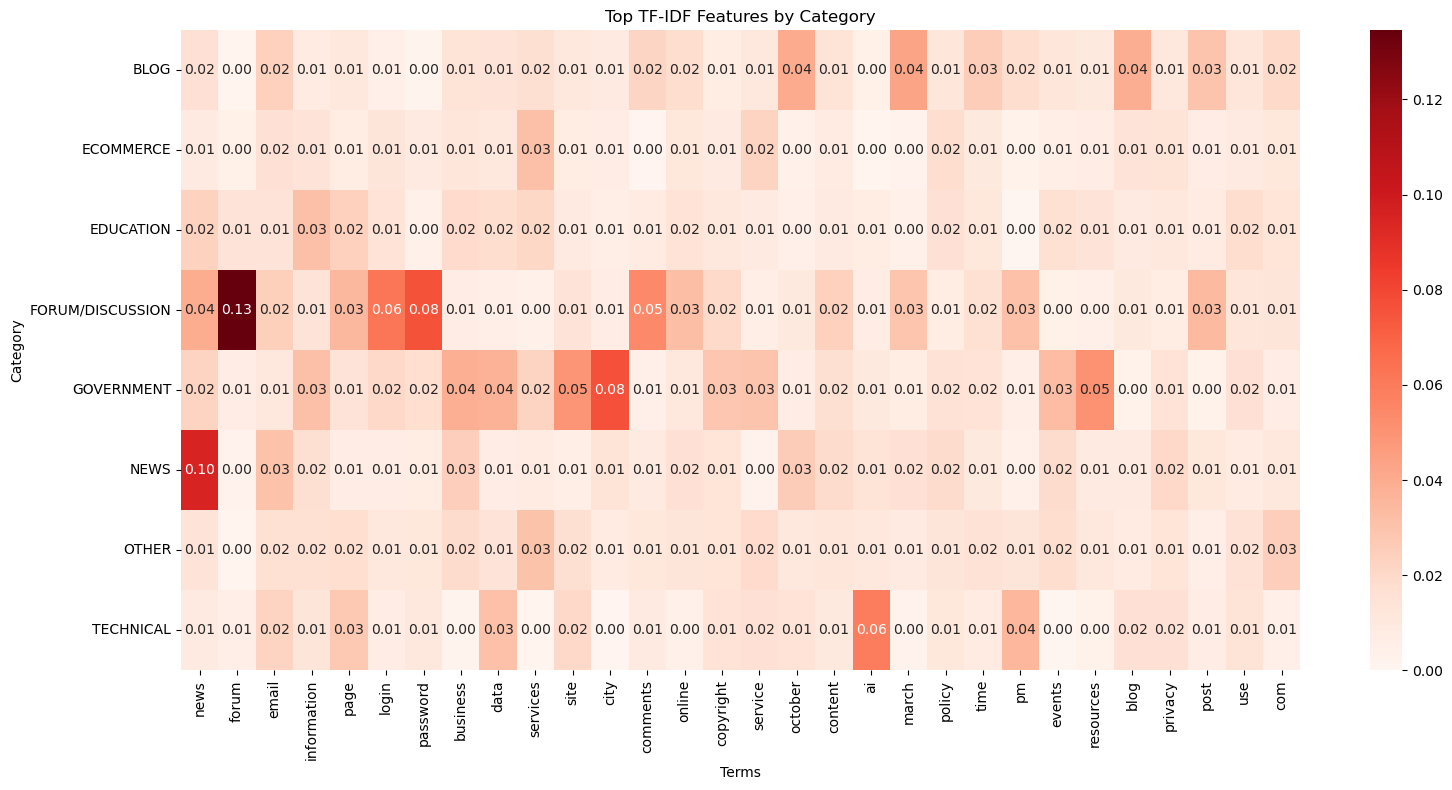

In [333]:
plt.figure(figsize=(16, 8))

sns.heatmap(
    plot_data,
    annot=True,
    fmt=".2f",
    cmap="Reds"
)

plt.title("Top TF-IDF Features by Category")
plt.ylabel("Category")
plt.xlabel("Terms")

plt.tight_layout()
plt.show()

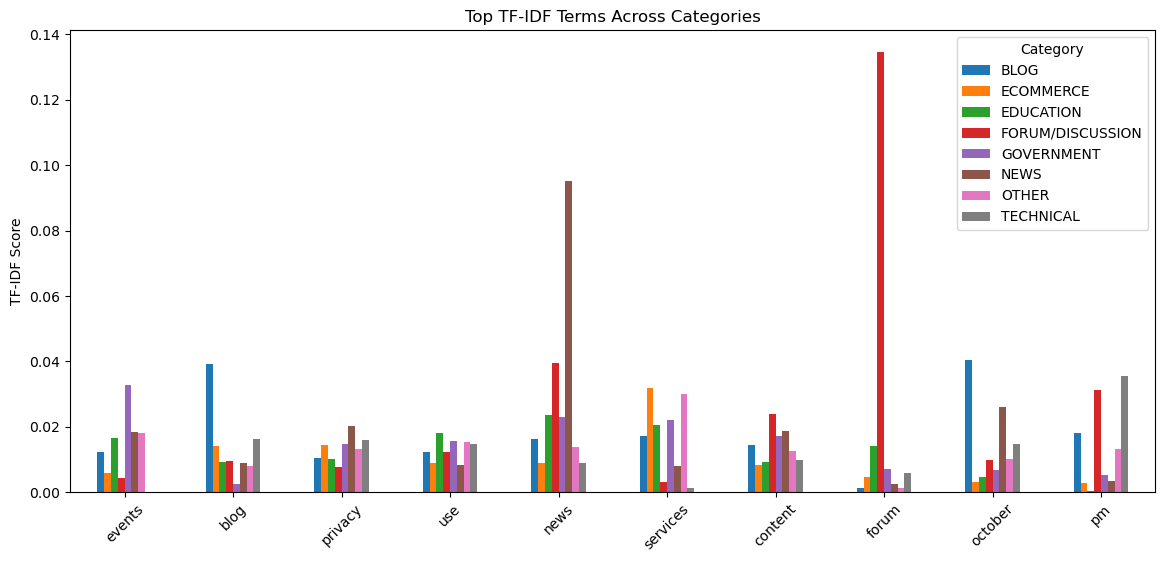

In [334]:
top10 = plot_data.sample(n=10, axis=1)

top10.T.plot(
    kind='bar',
    figsize=(14, 6)
)

plt.title("Top TF-IDF Terms Across Categories")
plt.ylabel("TF-IDF Score")
plt.xticks(rotation=45)

plt.show()

### **4. Classification Algorithm Implementation**

Here we will implement different classification algorithms on our labeled data to select model which had the best trade-off values (F1, Precision, Recall). We won't be using accuracy as it measures the total percentage of correct guesses, which might be missleading when we have class imbalance

In [335]:
# Loading sklearn libraries for model implementation and evaluation
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import cross_validate, StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import make_scorer, precision_score, recall_score, f1_score

In [336]:
# Setting up cross-validation and scoring metrics and will keep random seed 42 for reproducibility
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scoring = {
    'accuracy': 'accuracy',
    'precision': make_scorer(precision_score, average='weighted', zero_division=0),
    'recall':    make_scorer(recall_score,    average='weighted', zero_division=0),
    'f1':        make_scorer(f1_score,        average='weighted', zero_division=0)
}

In [337]:
# Defining the models to be evaluated
models = {
    'LogisticRegression': (
        LogisticRegression(max_iter=1000, class_weight='balanced'),
        {'C': [0.1, 1.0, 5.0, 10.0]}
    ),
    'KNN': (
        KNeighborsClassifier(metric='cosine', n_jobs=-1),
        {'n_neighbors': [3, 5, 7, 11], 'weights': ['uniform', 'distance']}
    ),
    'SVM': (
        SVC(class_weight='balanced'),
        {'C': [0.1, 1.0, 5.0], 'kernel': ['linear', 'rbf']}
    ),
    'RandomForest': (
        RandomForestClassifier(class_weight='balanced', random_state=42, n_jobs=-1),
        {'n_estimators': [100, 200], 'max_depth': [None, 10, 20]}
    ),
    'DecisionTree': (
        DecisionTreeClassifier(class_weight='balanced', random_state=42),
        {'max_depth': [5, 10, 15, None]}
    ),
    'MultinomialNB': (
        MultinomialNB(),
        {'alpha': [0.1, 0.5, 1.0], 'fit_prior': [True, False]}
    )
}

In [338]:
# Storing all results in a dictionary
results = {}
for name, (model, params) in models.items():
    # Select the best model based on F1 score (refit='f1')
    gs = GridSearchCV(model, params, cv=cv, scoring=scoring, refit='f1', n_jobs=-1)
    gs.fit(matrix_df.drop(columns=['Category']), matrix_df['Category'])
    
    # Extract scores for the best parameter combination
    best_idx = gs.best_index_
    cv_results = gs.cv_results_
    
    results[name] = {
        'best_params': gs.best_params_,
        'accuracy':  cv_results['mean_test_accuracy'][best_idx],
        'precision': cv_results['mean_test_precision'][best_idx],
        'recall':    cv_results['mean_test_recall'][best_idx],
        'f1':        cv_results['mean_test_f1'][best_idx]
    }
    
    print(f"\n{name}")
    print(f"  Best params: {gs.best_params_}")
    print(f"  Accuracy:    {results[name]['accuracy']:.4f}")
    print(f"  Precision:   {results[name]['precision']:.4f}")
    print(f"  Recall:      {results[name]['recall']:.4f}")
    print(f"  F1:          {results[name]['f1']:.4f}")


LogisticRegression
  Best params: {'C': 10.0}
  Accuracy:    0.5336
  Precision:   0.5311
  Recall:      0.5336
  F1:          0.5226

KNN
  Best params: {'n_neighbors': 11, 'weights': 'distance'}
  Accuracy:    0.5000
  Precision:   0.5104
  Recall:      0.5000
  F1:          0.4834

SVM
  Best params: {'C': 1.0, 'kernel': 'linear'}
  Accuracy:    0.5185
  Precision:   0.5462
  Recall:      0.5185
  F1:          0.5072

RandomForest
  Best params: {'max_depth': 10, 'n_estimators': 200}
  Accuracy:    0.5354
  Precision:   0.5436
  Recall:      0.5354
  F1:          0.5249

DecisionTree
  Best params: {'max_depth': None}
  Accuracy:    0.3960
  Precision:   0.4153
  Recall:      0.3960
  F1:          0.3970

MultinomialNB
  Best params: {'alpha': 1.0, 'fit_prior': False}
  Accuracy:    0.5067
  Precision:   0.4976
  Recall:      0.5067
  F1:          0.4979


In [339]:
summary = pd.DataFrame(results).T.drop(columns='best_params')
summary = summary.astype(float).round(4)
print("\n--- Summary ---")
print(summary.to_string())


--- Summary ---
                    accuracy  precision  recall      f1
LogisticRegression    0.5336     0.5311  0.5336  0.5226
KNN                   0.5000     0.5104  0.5000  0.4834
SVM                   0.5185     0.5462  0.5185  0.5072
RandomForest          0.5354     0.5436  0.5354  0.5249
DecisionTree          0.3960     0.4153  0.3960  0.3970
MultinomialNB         0.5067     0.4976  0.5067  0.4979


**Interpretation**

Based on the above results "Logistic Regression" and "Random Forest" have tied (based on accuracy) and has the highest overall performance, but Logistic Regression can be considered the most optimized due to its superior balance and precision-focused metrics. Now, the F1-score is the harmonic mean of precision and recall and is the preferred metric for identifying the best-balanced model. Logistic Regression achieved the highest F1-score (0.5335), indicating it handled the trade-off between False Positives and False Negatives better than any other model.

### **5. Training the Model with best Trade-Off Results**

Here we will train the model on our label dataset and store the model. Then we will use the trained model and test that model on our original data and look at the results

In [368]:
# Defining train test libraries
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report

In [369]:
# Creating training data and test data for the best model (Logistic Regression in this case)
X = matrix_df.drop(columns=['Category'])
y = matrix_df['Category']

In [370]:
# Using stratified sampling to maintain class distribution in train and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

#### **5.1 Defining, Training, and Testing Logistic Regression**

In [371]:
# Defining the models to be evaluated
lr_model = LogisticRegression(max_iter=1000, class_weight='balanced', C=1.0)

In [372]:
# Fitting the model on the training data
lr_model.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,'balanced'
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [373]:
y_test_pred = lr_model.predict(X_test)

print("Test Accuracy:", lr_model.score(X_test, y_test))
print(classification_report(y_test, y_test_pred,zero_division=0))

Test Accuracy: 0.45
                  precision    recall  f1-score   support

            BLOG       0.65      0.44      0.52        25
       ECOMMERCE       0.50      0.57      0.53        23
       EDUCATION       0.27      0.33      0.30        12
FORUM/DISCUSSION       0.70      0.78      0.74         9
      GOVERNMENT       0.00      0.00      0.00         3
            NEWS       0.33      0.33      0.33         9
           OTHER       0.41      0.50      0.45        32
       TECHNICAL       0.00      0.00      0.00         7

        accuracy                           0.45       120
       macro avg       0.36      0.37      0.36       120
    weighted avg       0.44      0.45      0.44       120



#### **5.2 Defining, Training, and Testing Random Forest**

In [374]:
# Fitting the Random Forest model on the training data
rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=None,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

,n_estimators,200
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [375]:
y_test_pred = rf_model.predict(X_test)

print("Test Accuracy:", rf_model.score(X_test, y_test))
print(classification_report(y_test, y_test_pred,zero_division=0))

Test Accuracy: 0.5
                  precision    recall  f1-score   support

            BLOG       0.58      0.60      0.59        25
       ECOMMERCE       0.72      0.57      0.63        23
       EDUCATION       1.00      0.25      0.40        12
FORUM/DISCUSSION       0.70      0.78      0.74         9
      GOVERNMENT       0.00      0.00      0.00         3
            NEWS       0.00      0.00      0.00         9
           OTHER       0.35      0.69      0.46        32
       TECHNICAL       0.00      0.00      0.00         7

        accuracy                           0.50       120
       macro avg       0.42      0.36      0.35       120
    weighted avg       0.50      0.50      0.46       120



#### **5.3 Implementing Random Forest Algorithm on original Data"**

In [376]:
original_matrix_df = pd.DataFrame(original_tfidf_matrix.toarray(), columns=vectorizer.get_feature_names_out())
print("--"*50)
print("Original TFIDF Matrix as a DataFrame:")
print("--"*50)
original_matrix_df

----------------------------------------------------------------------------------------------------
Original TFIDF Matrix as a DataFrame:
----------------------------------------------------------------------------------------------------


,30min,3d,3d models,ab,able,absolutely,ac,accept,access,accessibility,...,yang,year,years,years ago,yes,yoga,york,young,zone,zu
0,0.0,0.0,0.0,0.000000,0.005753,0.000000,0.0,0.010571,0.009154,0.0,...,0.0,0.000000,0.000000,0.000000,0.005582,0.0,0.000000,0.000000,0.0,0.0
1,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.0,0.007422,0.000000,0.0,...,0.0,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.0,0.0
2,0.0,0.0,0.0,0.000000,0.010942,0.000000,0.0,0.000000,0.000000,0.0,...,0.0,0.000000,0.007899,0.000000,0.021230,0.0,0.000000,0.000000,0.0,0.0
3,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.0,...,0.0,0.018202,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.0,0.0
4,0.0,0.0,0.0,0.013187,0.035821,0.009825,0.0,0.000000,0.007124,0.0,...,0.0,0.032018,0.058183,0.021352,0.000000,0.0,0.009595,0.009906,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6309,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.0,0.079678,0.000000,0.0,...,0.0,0.031009,0.000000,0.000000,0.000000,0.0,0.000000,0.047969,0.0,0.0
6310,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.0,...,0.0,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.0,0.0
6311,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.0,0.031203,0.000000,0.0,...,0.0,0.024286,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.0,0.0
6312,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.0,...,0.0,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.0,0.0


In [377]:
results = rf_model.predict(original_tfidf_matrix)

/Users/tejasphanse/miniconda3/envs/pyenv/lib/python3.12/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


In [378]:
# Convert sparse matrix to dense DataFrame
df_tfidf = pd.DataFrame(original_tfidf_matrix.toarray(), columns=vectorizer.get_feature_names_out())

# Add the prediction column
df_tfidf['Predicted_Category'] = rf_model.predict(original_tfidf_matrix)
    

/Users/tejasphanse/miniconda3/envs/pyenv/lib/python3.12/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


In [379]:
print("--"*50)
print("TFIDF DataFrame with Predictions:")
print("--"*50)
df_tfidf

----------------------------------------------------------------------------------------------------
TFIDF DataFrame with Predictions:
----------------------------------------------------------------------------------------------------


,30min,3d,3d models,ab,able,absolutely,ac,accept,access,accessibility,...,year,years,years ago,yes,yoga,york,young,zone,zu,Predicted_Category
0,0.0,0.0,0.0,0.000000,0.005753,0.000000,0.0,0.010571,0.009154,0.0,...,0.000000,0.000000,0.000000,0.005582,0.0,0.000000,0.000000,0.0,0.0,EDUCATION
1,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.0,0.007422,0.000000,0.0,...,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.0,0.0,OTHER
2,0.0,0.0,0.0,0.000000,0.010942,0.000000,0.0,0.000000,0.000000,0.0,...,0.000000,0.007899,0.000000,0.021230,0.0,0.000000,0.000000,0.0,0.0,FORUM/DISCUSSION
3,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.0,...,0.018202,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.0,0.0,BLOG
4,0.0,0.0,0.0,0.013187,0.035821,0.009825,0.0,0.000000,0.007124,0.0,...,0.032018,0.058183,0.021352,0.000000,0.0,0.009595,0.009906,0.0,0.0,NEWS
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6309,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.0,0.079678,0.000000,0.0,...,0.031009,0.000000,0.000000,0.000000,0.0,0.000000,0.047969,0.0,0.0,ECOMMERCE
6310,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.0,...,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.0,0.0,BLOG
6311,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.0,0.031203,0.000000,0.0,...,0.024286,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.0,0.0,OTHER
6312,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.0,...,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.0,0.0,ECOMMERCE


In [380]:
print("Category distribution in the original dataset:\n",df_tfidf['Predicted_Category'].value_counts())

Category distribution in the original dataset:
 Predicted_Category
OTHER               2996
ECOMMERCE           1521
BLOG                1216
EDUCATION            227
FORUM/DISCUSSION     216
NEWS                  94
TECHNICAL             34
GOVERNMENT            10
Name: count, dtype: int64


#### **5.4 Visualization of Model Results**

In [381]:
category_means = df_tfidf.groupby('Predicted_Category').mean()

for category in category_means.index:
    top = category_means.loc[category].sort_values(ascending=False).head(10)
    print(f"\nCategory: {category}")
    print(top)


Category: BLOG
november     0.046460
december     0.045006
august       0.040454
september    0.040449
march        0.040363
april        0.039525
february     0.039456
october      0.039295
january      0.037700
june         0.037087
Name: BLOG, dtype: float64

Category: ECOMMERCE
cart           0.061856
products       0.059172
product        0.047733
price          0.047572
accessories    0.046776
add            0.042111
shop           0.041709
view           0.036573
account        0.031509
shipping       0.030972
Name: ECOMMERCE, dtype: float64

Category: EDUCATION
research      0.102780
university    0.098634
students      0.067248
library       0.057860
student       0.050373
study         0.045414
education     0.041210
school        0.039718
college       0.035412
news          0.034796
Name: EDUCATION, dtype: float64

Category: FORUM/DISCUSSION
forum       0.191802
board       0.075026
topics      0.072744
posts       0.069930
login       0.060760
password    0.059231
registe

In [382]:
# Creating Plotting ready data--
top_n = 30

# Get globally important features
top_features = (
    category_means.mean()
    .sort_values(ascending=False)
    .head(top_n)
    .index
)

plot_data = category_means[top_features]

print("--"*50)
print("Plot Ready Data:")
print("--"*50)
plot_data

----------------------------------------------------------------------------------------------------
Plot Ready Data:
----------------------------------------------------------------------------------------------------


,news,forum,data,information,business,policy,page,email,site,research,...,password,register,community,public,pm,permits,board,service,cookies,help
Predicted_Category,,,,,,,,,,,,,,,,,,,,,
BLOG,0.030200,0.002816,0.015373,0.013128,0.020497,0.017610,0.012253,0.023770,0.011341,0.007429,...,0.005935,0.003548,0.014921,0.009315,0.016993,0.000693,0.006867,0.011261,0.017778,0.016833
ECOMMERCE,0.012639,0.001190,0.014462,0.023185,0.013289,0.029852,0.015447,0.022772,0.012411,0.004697,...,0.011594,0.009995,0.004984,0.003558,0.008448,0.000172,0.003712,0.025403,0.016028,0.014714
EDUCATION,0.034796,0.002858,0.032653,0.033728,0.021184,0.025607,0.013354,0.013609,0.012923,0.102780,...,0.004591,0.006903,0.019647,0.023242,0.004047,0.001433,0.014942,0.010842,0.013068,0.018439
FORUM/DISCUSSION,0.033533,0.191802,0.014056,0.019926,0.003607,0.011890,0.038522,0.023017,0.015532,0.003704,...,0.059231,0.051854,0.034367,0.007568,0.041802,0.000000,0.075026,0.009165,0.023567,0.022079
GOVERNMENT,0.020054,0.009152,0.019576,0.026346,0.050217,0.010639,0.017960,0.009142,0.056021,0.004102,...,0.022844,0.024158,0.015345,0.028733,0.004004,0.126428,0.009314,0.034548,0.009323,0.002771
NEWS,0.173234,0.003053,0.011887,0.011750,0.031517,0.026514,0.007135,0.029643,0.011800,0.013260,...,0.009216,0.006002,0.019101,0.033182,0.007339,0.001309,0.010833,0.005849,0.003132,0.007540
OTHER,0.022698,0.001712,0.020256,0.021467,0.020892,0.021612,0.022819,0.017765,0.014158,0.008820,...,0.009102,0.006272,0.016445,0.009500,0.013101,0.000468,0.007246,0.016840,0.015393,0.015482
TECHNICAL,0.012973,0.005757,0.040202,0.014951,0.001617,0.016413,0.031742,0.015045,0.017861,0.005413,...,0.012974,0.024719,0.007680,0.016308,0.035477,0.000000,0.002281,0.014587,0.026390,0.026520


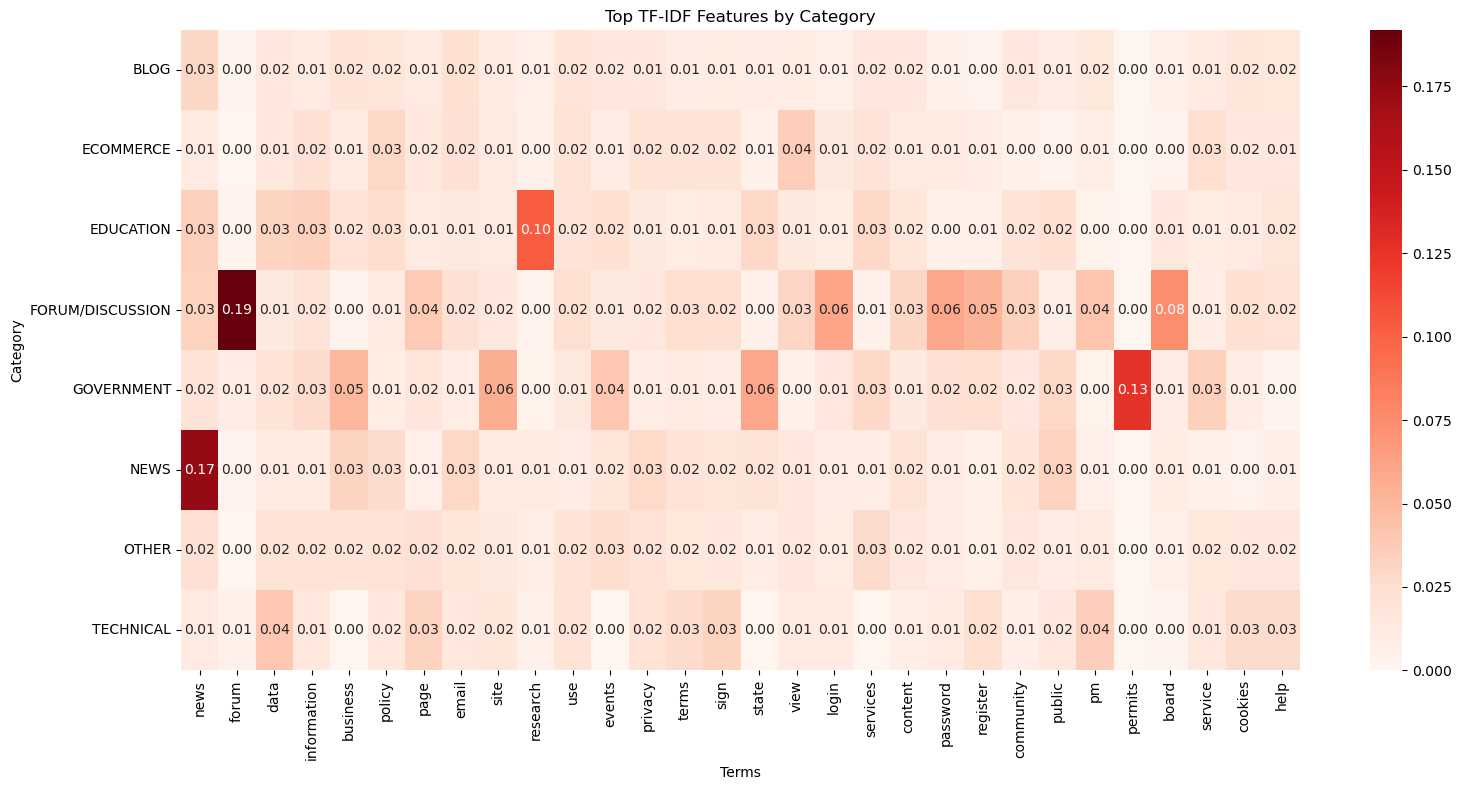

In [383]:
plt.figure(figsize=(16, 8))

sns.heatmap(
    plot_data,
    annot=True,
    fmt=".2f",
    cmap="Reds"
)

plt.title("Top TF-IDF Features by Category")
plt.ylabel("Category")
plt.xlabel("Terms")

plt.tight_layout()
plt.show()

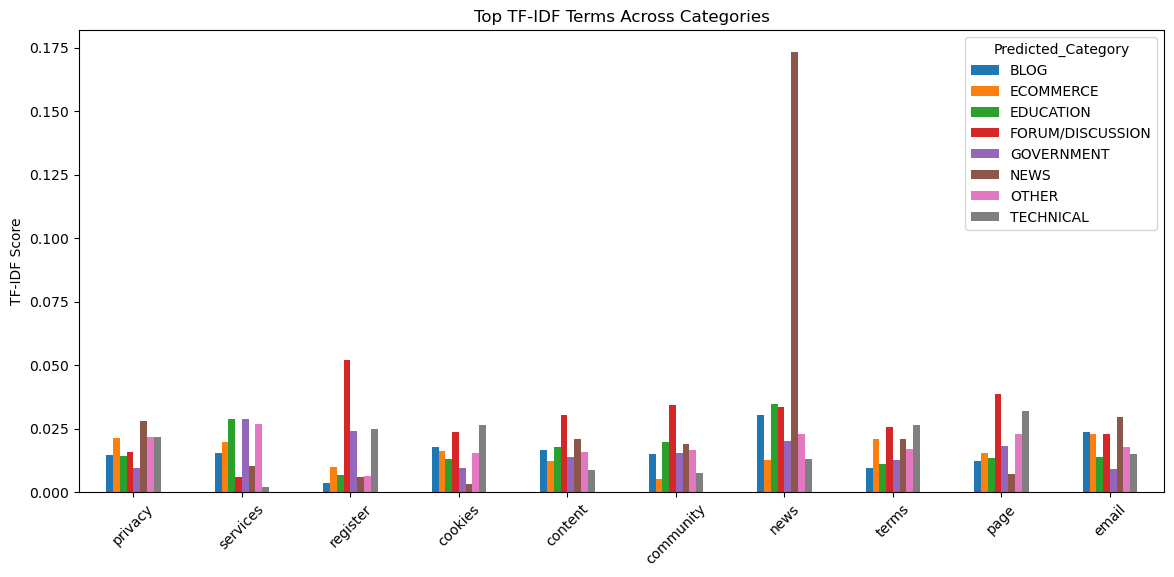

In [384]:
rand10 = plot_data.sample(n=10, axis=1)

rand10.T.plot(
    kind='bar',
    figsize=(14, 6)
)

plt.title("Top TF-IDF Terms Across Categories")
plt.ylabel("TF-IDF Score")
plt.xticks(rotation=45)

plt.show()

#### **5.5 Misclassification Report**

Here we will compare original label given to us with the predicted labels 

In [385]:
df_tfidf['page_id'] = original_data_analysis['page_id'].values

In [386]:
original_labels_list = data['manual_label_final'].tolist()
predicted_labels_list = df_tfidf['Predicted_Category'].tolist()

print("--"*50)
print("Original Labels Distribution:\n", pd.Series(original_labels_list).value_counts())
print("--"*50)
print("Predicted Labels Distribution:\n", pd.Series(predicted_labels_list).value_counts())


----------------------------------------------------------------------------------------------------
Original Labels Distribution:
 OTHER               158
BLOG                123
ECOMMERCE           114
EDUCATION            61
NEWS                 47
FORUM/DISCUSSION     46
TECHNICAL            34
GOVERNMENT           13
Name: count, dtype: int64
----------------------------------------------------------------------------------------------------
Predicted Labels Distribution:
 OTHER               2996
ECOMMERCE           1521
BLOG                1216
EDUCATION            227
FORUM/DISCUSSION     216
NEWS                  94
TECHNICAL             34
GOVERNMENT            10
Name: count, dtype: int64


In [387]:
# calculating misclassification rate
misclassification = {}

for i in range(len(original_labels_list)):
    og_page_id = data.loc[i, 'page_id']
    og_label = original_labels_list[i]
    pred_label = df_tfidf[df_tfidf['page_id'] == og_page_id]['Predicted_Category'].values[0]
    if og_label != pred_label:
        print(f"Misclassified Page ID: {og_page_id} -- Original Label: {og_label} -- Predicted Label: {pred_label}")
        misclassification[og_page_id] = {
            'page_id': og_page_id,
            'original_label': og_label,
            'predicted_label': pred_label
        }

Misclassified Page ID: 658.0 -- Original Label: BLOG -- Predicted Label: OTHER
Misclassified Page ID: 662.0 -- Original Label: BLOG -- Predicted Label: OTHER
Misclassified Page ID: 685.0 -- Original Label: EDUCATION -- Predicted Label: OTHER
Misclassified Page ID: 545.0 -- Original Label: ECOMMERCE -- Predicted Label: OTHER
Misclassified Page ID: 927.0 -- Original Label: ECOMMERCE -- Predicted Label: BLOG
Misclassified Page ID: 937.0 -- Original Label: EDUCATION -- Predicted Label: OTHER
Misclassified Page ID: 943.0 -- Original Label: GOVERNMENT -- Predicted Label: ECOMMERCE
Misclassified Page ID: 955.0 -- Original Label: GOVERNMENT -- Predicted Label: OTHER
Misclassified Page ID: 1197.0 -- Original Label: OTHER -- Predicted Label: BLOG
Misclassified Page ID: 1218.0 -- Original Label: OTHER -- Predicted Label: BLOG
Misclassified Page ID: 311.0 -- Original Label: TECHNICAL -- Predicted Label: OTHER
Misclassified Page ID: 312.0 -- Original Label: EDUCATION -- Predicted Label: OTHER
Miscl

In [388]:
# Total misclassification count
print("--"*50)
print(f"Total Misclassifications: {len(misclassification)} out of {len(original_labels_list)}")
print("--"*50)

----------------------------------------------------------------------------------------------------
Total Misclassifications: 60 out of 596
----------------------------------------------------------------------------------------------------


In [389]:
# Converting misclassification dictionary to a DataFrame for better visualization
misclassification_df = pd.DataFrame.from_dict(misclassification, orient='index')
print("--"*50)
print("Misclassified Instances:")
print("--"*50)
misclassification_df

----------------------------------------------------------------------------------------------------
Misclassified Instances:
----------------------------------------------------------------------------------------------------


,page_id,original_label,predicted_label
658.0,658.0,BLOG,OTHER
662.0,662.0,BLOG,OTHER
685.0,685.0,EDUCATION,OTHER
545.0,545.0,ECOMMERCE,OTHER
927.0,927.0,ECOMMERCE,BLOG
937.0,937.0,EDUCATION,OTHER
943.0,943.0,GOVERNMENT,ECOMMERCE
955.0,955.0,GOVERNMENT,OTHER
1197.0,1197.0,OTHER,BLOG
1218.0,1218.0,OTHER,BLOG


In [390]:
# Missclassification distribution
print("--"*50)
print("Misclassification Distribution:\n", misclassification_df['predicted_label'].value_counts())
print("--"*50)

----------------------------------------------------------------------------------------------------
Misclassification Distribution:
 predicted_label
OTHER               41
BLOG                11
ECOMMERCE            5
FORUM/DISCUSSION     3
Name: count, dtype: int64
----------------------------------------------------------------------------------------------------


**Interpretation**

In the labeled dataset, we had 596 rows. Considering our best accuracy of 53% from the Random Forest model. When this model was tested on original data, about 10% of the data was misclassified (comparision was based on page_id and associated labels from labeled dataset).

Most of the misclassified rows were predicted as the “OTHER” category. This may be because the algorithms rely heavily on the TF-IDF matrix, where each value assigned to a word depends on its frequency across all documents. In reality, the model is not fully aware of the semantic context, which can lead to misclassification.